# Lab 12: Exploratory Data Analysis (EDA)
## IBM Data Analytics Capstone Project 
### Objective: Analyze distributions, relationships, trends and patterns in the Stack Overflow Developer Survey dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display all columns
pd.set_option('display.max_columns', None)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

In [2]:
# Check missing values in critical columns
critical_cols = ['Employment', 'JobSat', 'RemoteWork', 'YearsCodePro']
print("Missing values in critical columns:")
for col in critical_cols:
    print(f"  {col}: {df[col].isnull().sum()}")

# Handle missing values
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
df['Employment'] = df['Employment'].fillna(df['Employment'].mode()[0])
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].median())
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['YearsCodePro'] = df['YearsCodePro'].fillna(df['YearsCodePro'].median())

print("\nAfter handling missing values:")
for col in critical_cols:
    print(f"  {col}: {df[col].isnull().sum()}")
print("Missing values handled!")

Missing values in critical columns:
  Employment: 0
  JobSat: 36311
  RemoteWork: 10631
  YearsCodePro: 13827

After handling missing values:
  Employment: 0
  JobSat: 0
  RemoteWork: 0
  YearsCodePro: 0
Missing values handled!


Median Job Satisfaction by Experience Range:
  ExperienceRange  JobSat
0       0-5 years     7.0
1      5-10 years     7.0
2     10-20 years     7.0
3       20+ years     7.0


/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_84326/1249651776.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp_satisfaction, x='ExperienceRange', y='JobSat', palette='viridis')


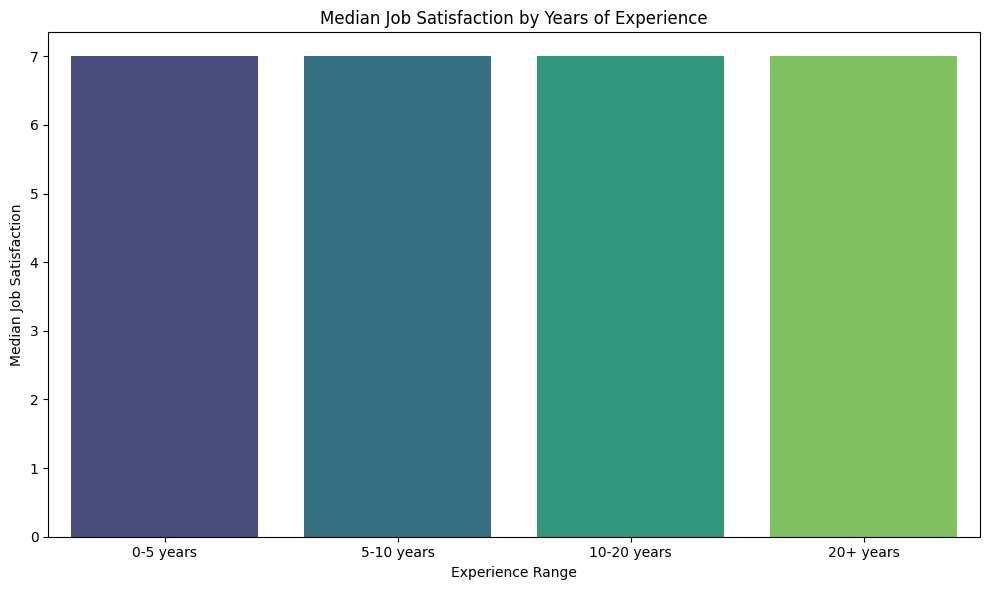

Visualization saved!


In [3]:
# Create experience ranges
bins = [0, 5, 10, 20, 100]
labels = ['0-5 years', '5-10 years', '10-20 years', '20+ years']
df['ExperienceRange'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels)

# Calculate median JobSat per experience range
exp_satisfaction = df.groupby('ExperienceRange', observed=True)['JobSat'].median().reset_index()
print("Median Job Satisfaction by Experience Range:")
print(exp_satisfaction)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=exp_satisfaction, x='ExperienceRange', y='JobSat', palette='viridis')
plt.title('Median Job Satisfaction by Years of Experience')
plt.xlabel('Experience Range')
plt.ylabel('Median Job Satisfaction')
plt.tight_layout()
plt.savefig('exp_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_84326/740134031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='JobSat', palette='viridis')


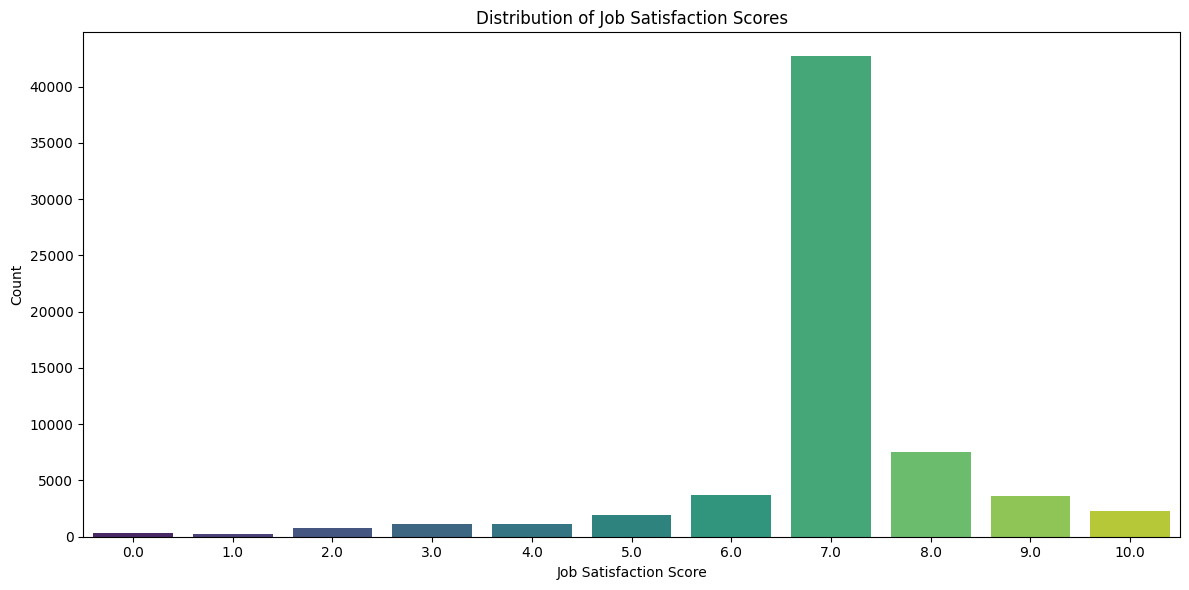

Job Satisfaction distribution saved!


In [4]:
# Count plot of JobSat distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='JobSat', palette='viridis')
plt.title('Distribution of Job Satisfaction Scores')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('jobsat_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Job Satisfaction distribution saved!")

/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_84326/4209487083.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RemoteWork', palette='Set2')


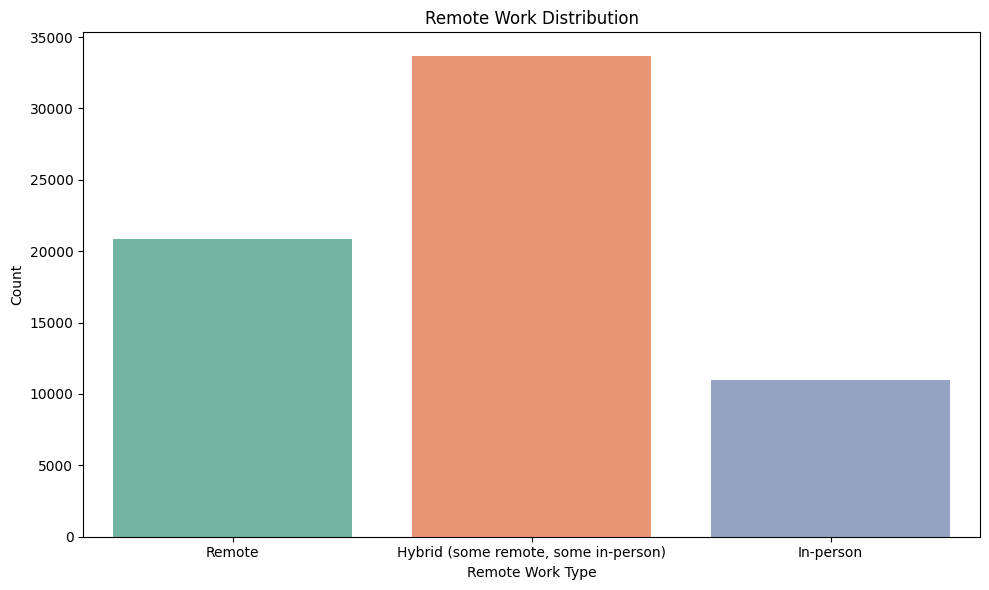


Cross-tabulation: RemoteWork vs Employment (Top 4):
Employment                            Employed, full-time  \
RemoteWork                                                  
Hybrid (some remote, some in-person)                17296   
In-person                                            8552   
Remote                                              13193   

Employment                            Employed, full-time;Independent contractor, freelancer, or self-employed  \
RemoteWork                                                                                                       
Hybrid (some remote, some in-person)                                               1330                          
In-person                                                                           366                          
Remote                                                                             1861                          

Employment                            Independent contractor, freelanc

In [5]:
# Count plot for RemoteWork distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='RemoteWork', palette='Set2')
plt.title('Remote Work Distribution')
plt.xlabel('Remote Work Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('remotework_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Cross-tabulation of RemoteWork by Employment
print("\nCross-tabulation: RemoteWork vs Employment (Top 4):")
top_employment = df['Employment'].value_counts().head(4).index
crosstab = pd.crosstab(
    df[df['Employment'].isin(top_employment)]['RemoteWork'],
    df[df['Employment'].isin(top_employment)]['Employment']
)
print(crosstab)

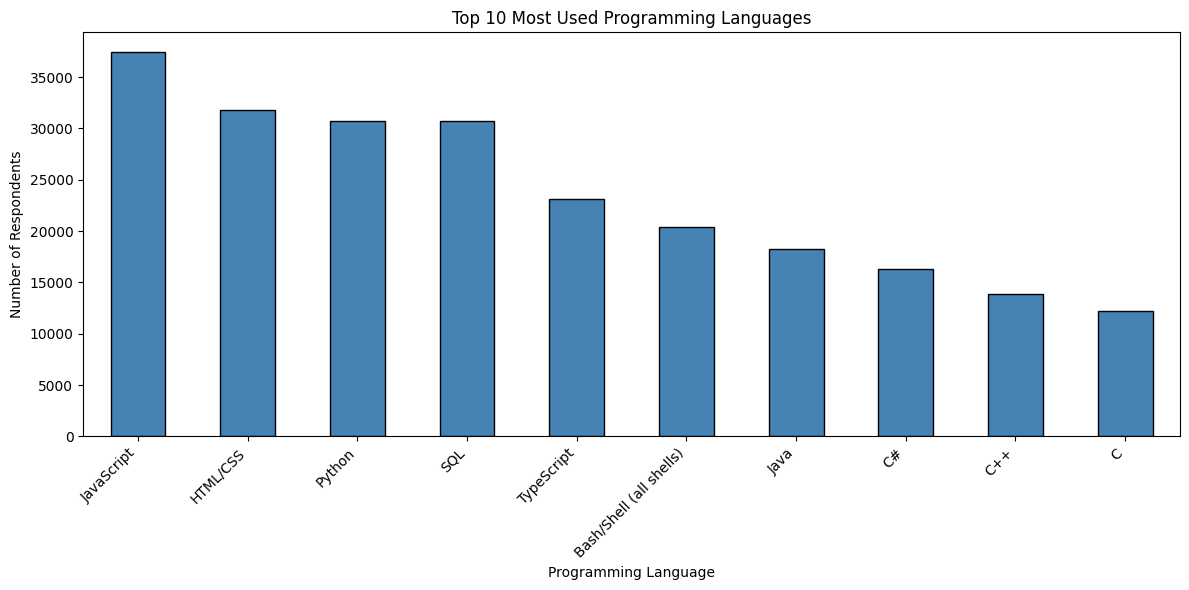


Top 5 languages by region:

United States of America:
LanguageHaveWorkedWith
JavaScript                 6849
Python                     6238
SQL                        5766
HTML/CSS                   5754
Bash/Shell (all shells)    4776
Name: count, dtype: int64

Germany:
LanguageHaveWorkedWith
JavaScript                 2732
Python                     2640
HTML/CSS                   2514
SQL                        2297
Bash/Shell (all shells)    1970
Name: count, dtype: int64

India:
LanguageHaveWorkedWith
JavaScript    2730
HTML/CSS      2322
Python        2128
SQL           1986
Java          1549
Name: count, dtype: int64


In [6]:
# Top programming languages globally
languages_series = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
top_languages = languages_series.value_counts().head(10)

plt.figure(figsize=(12, 6))
top_languages.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Most Used Programming Languages')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_languages.png', dpi=150, bbox_inches='tight')
plt.show()

# Top languages by top 3 regions
print("\nTop 5 languages by region:")
top_countries = ['United States of America', 'Germany', 'India']
for country in top_countries:
    country_df = df[df['Country'] == country]
    lang = country_df['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
    print(f"\n{country}:")
    print(lang.value_counts().head(5))

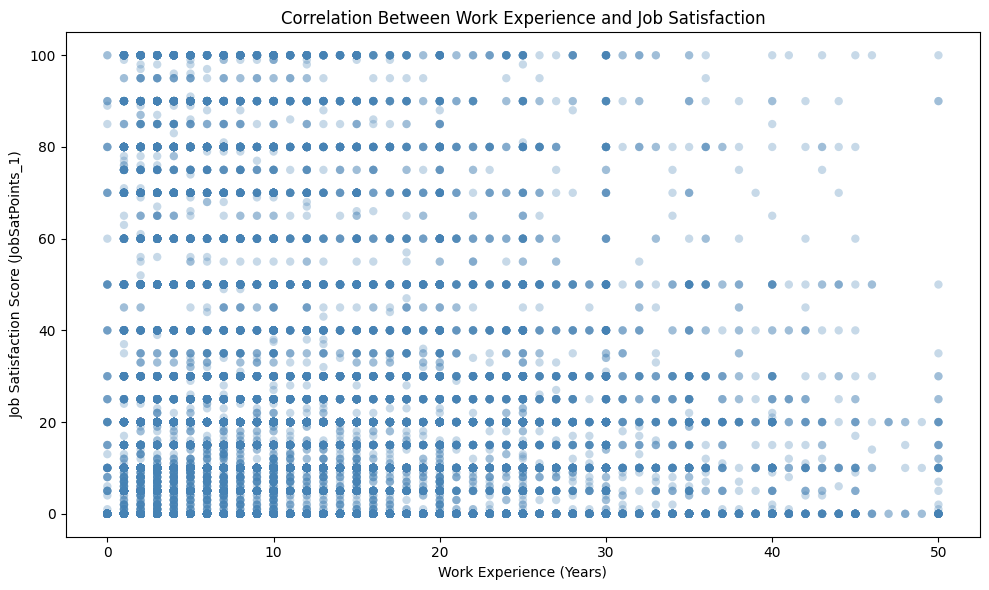

 Scatter plot saved!


In [7]:
# Scatter plot - WorkExp vs JobSatPoints_1
plt.figure(figsize=(10, 6))
plt.scatter(df['WorkExp'], df['JobSatPoints_1'], 
            alpha=0.3, color='steelblue', edgecolors='none')
plt.title('Correlation Between Work Experience and Job Satisfaction')
plt.xlabel('Work Experience (Years)')
plt.ylabel('Job Satisfaction Score (JobSatPoints_1)')
plt.tight_layout()
plt.savefig('exp_vs_jobsat_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter plot saved!")

Cross-tabulation: Education Level vs Employment Type:
Employment                                          Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                1059   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      16806   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                   11011   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     2073   
Secondary school (e.g. American high school, Ge...                 1460   
Some college/university study without earning a...                 3579   

Employment                                          Employed, full-time;Independent contractor, freelancer, or self-employed  \
EdLevel                                                                                                                        
Associate degree (A.A., A.S., etc.)                                                      

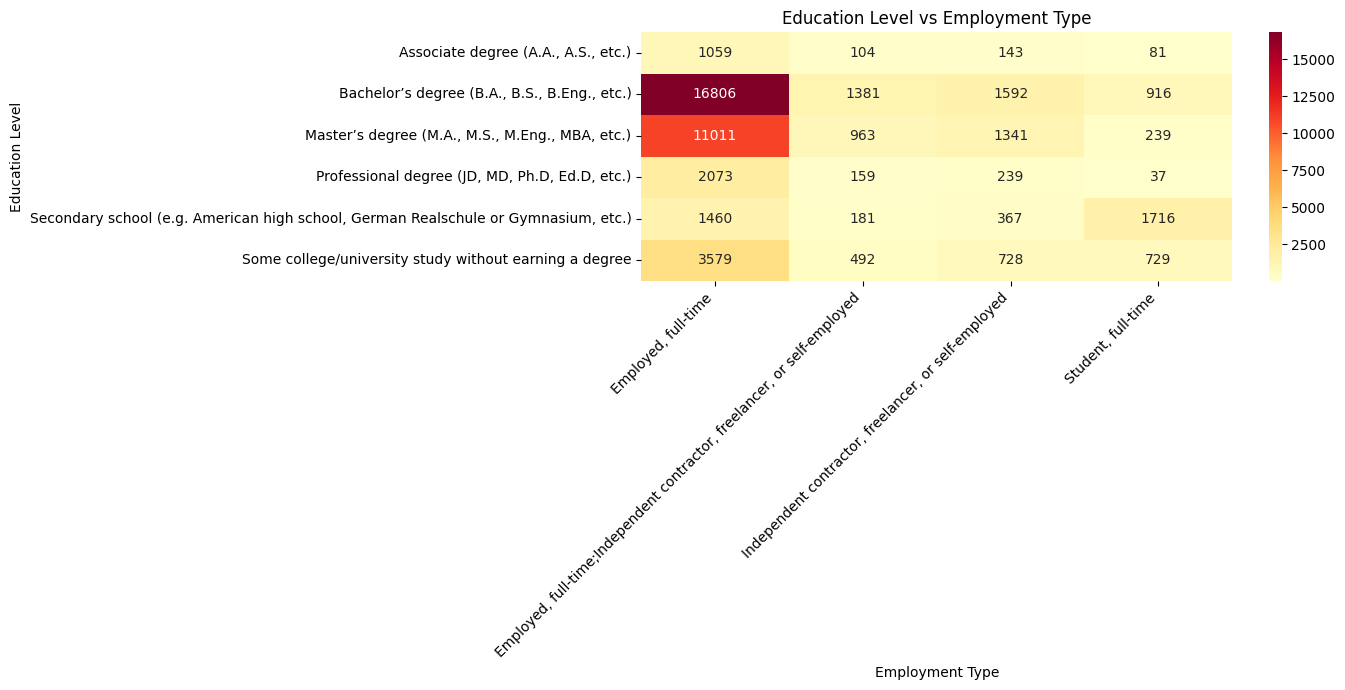

Cross-tabulation heatmap saved!


In [8]:
# Cross-tabulation of EdLevel vs Employment
top_employment = df['Employment'].value_counts().head(4).index
top_edlevel = df['EdLevel'].value_counts().head(6).index

crosstab = pd.crosstab(
    df[df['EdLevel'].isin(top_edlevel)]['EdLevel'],
    df[df['Employment'].isin(top_employment)]['Employment']
)
print("Cross-tabulation: Education Level vs Employment Type:")
print(crosstab)

# Visualize as heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Education Level vs Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Education Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('edlevel_vs_employment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cross-tabulation heatmap saved!")

In [9]:
# Save the cleaned and analyzed dataset
df.to_csv('survey_data_cleaned.csv', index=False)
print("Cleaned dataset saved as 'survey_data_cleaned.csv'")
print("Final shape:", df.shape)

# Summary of all analysis done
print("\n--- Lab 12 Summary ---")
print(f"Total respondents analyzed: {len(df):,}")
print(f"Countries represented: {df['Country'].nunique()}")
print(f"Most common employment: {df['Employment'].value_counts().index[0]}")
print(f"Most common remote work: {df['RemoteWork'].value_counts().index[0]}")
print(f"Median job satisfaction: {df['JobSat'].median()}")

Cleaned dataset saved as 'survey_data_cleaned.csv'
Final shape: (65437, 115)

--- Lab 12 Summary ---
Total respondents analyzed: 65,437
Countries represented: 185
Most common employment: Employed, full-time
Most common remote work: Hybrid (some remote, some in-person)
Median job satisfaction: 7.0
